# Alireza Mohammadshafie HW2

# Building a Neural Network to Solve XOR 

In this assignment, I implement a 2-layer neural network (1 hidden layer, 1 output layer) to solve the non-linear XOR problem. I will use NumPy for matrix operations and matplotlib to visualize the training loss.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Activation Function
I use the Sigmoid activation function to map linear combinations into a probability between 0 and 1.

In [2]:
def sigmoid(x):
    """Squashes numbers to a range between 0 and 1."""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """The derivative of the sigmoid function, used to calculate gradients."""
    return x * (1 - x)

## 2. Dataset Setup
The XOR logic gate only returns 1 if the inputs are strictly different. Otherwise, it returns 0.

In [3]:
X_train = np.array([[0, 0],
                    [0, 1],
                    [1, 0],
                    [1, 1]])

y_train = np.array([[0],
                    [1],
                    [1],
                    [0]])

## 3. Network Initialization
Our network architecture relies on 2 input neurons, 2 hidden neurons, and 1 output neuron. We initialize the weights with random values and the biases with zeros.

In [4]:
# Define the size of each layer
input_size = 2
hidden_size = 2
output_size = 1

weights_input_hidden = np.random.uniform(size=(input_size, hidden_size))
bias_hidden = np.zeros((1, hidden_size))

weights_hidden_output = np.random.uniform(size=(hidden_size, output_size))
bias_output = np.zeros((1, output_size))

In [5]:
weights_input_hidden

array([[0.37454012, 0.95071431],
       [0.73199394, 0.59865848]])

In [6]:
bias_hidden

array([[0., 0.]])

In [7]:
weights_hidden_output

array([[0.15601864],
       [0.15599452]])

In [8]:
bias_output

array([[0.]])

## 4. Training Loop (Forward and Backward Pass)


In [9]:
learning_rate = 0.045
epochs = 200000

loss_history = []

for epoch in range(epochs):
    
    # ==========================
    # FORWARD PROPAGATION
    # ==========================
    
    # 1. Calculate the hidden layer's output
    hidden_layer_raw = np.dot(X_train, weights_input_hidden) + bias_hidden
    hidden_layer_activation = sigmoid(hidden_layer_raw)
    
    # 2. Calculate the final output layer's guess
    output_layer_raw = np.dot(hidden_layer_activation, weights_hidden_output) + bias_output
    predictions = sigmoid(output_layer_raw)
    
    # ==========================
    # ERROR CALCULATION
    # ==========================
    
    # Calculate how wrong the predictions are
    error = y_train - predictions
    
    # Calculate Mean Absolute Error for graphing
    mean_error = np.mean(np.abs(error))
    loss_history.append(mean_error)
    
    # ==========================
    # BACKPROPAGATION
    # ==========================
    
    # 1. Gradients for the Output Layer
    d_predictions = error * sigmoid_derivative(predictions)
    
    # 2. Gradients for the Hidden Layer
    error_hidden_layer = d_predictions.dot(weights_hidden_output.T)
    d_hidden_layer = error_hidden_layer * sigmoid_derivative(hidden_layer_activation)
    
    # ==========================
    # UPDATE WEIGHTS & BIASES
    # ==========================
    
    weights_hidden_output += hidden_layer_activation.T.dot(d_predictions) * learning_rate
    bias_output += np.sum(d_predictions, axis=0, keepdims=True) * learning_rate
    
    weights_input_hidden += X_train.T.dot(d_hidden_layer) * learning_rate
    bias_hidden += np.sum(d_hidden_layer, axis=0, keepdims=True) * learning_rate

print("Training finished!")

Training finished!


## 5. Results and Visualization


Final raw predictions:
[[0.01374768]
 [0.98823805]
 [0.98823131]
 [0.01210864]]

Rounded predictions (Final XOR output):
[[0.]
 [1.]
 [1.]
 [0.]]


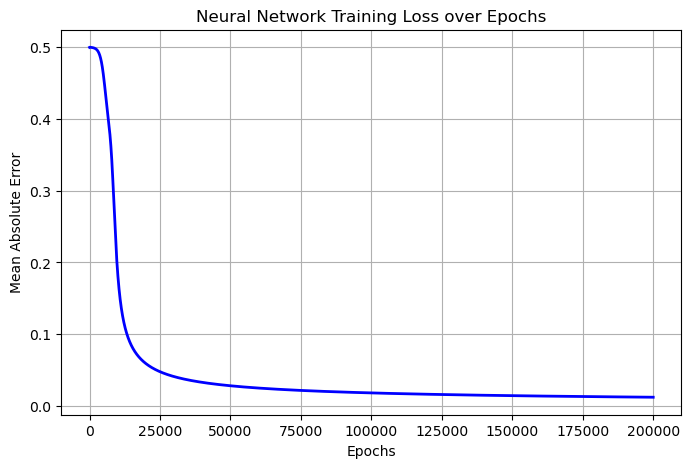

In [10]:
# Print the raw predictions and the rounded predictions
print("Final raw predictions:")
print(predictions)

print("\nRounded predictions (Final XOR output):")
print(np.round(predictions))

plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='blue', linewidth=2)
plt.title('Neural Network Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.grid(True)
plt.show()